In [1]:
!pip install pandas>=1.5.0 numpy>=1.23.0 torch>=2.0.0 scikit-learn>=1.2.0 optuna>=3.0.0 matplotlib>=3.6.0


In [2]:
# GEREKLİ KÜTÜPHANELER

import numpy as np
import pandas as pd

# PyTorch (Derin Öğrenme)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Scikit-learn (Veri İşleme & Metrikler)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
    roc_curve, precision_recall_curve,
    classification_report
)

# Görselleştirme ve Optimizasyon
import matplotlib.pyplot as plt
import optuna
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# DEVICE AYARI

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [ ]:
# VERİ SETİNİN YÜKLENMESİ

df = pd.read_csv("/content/drive/MyDrive/veri madenciliği 2/diabetes.csv")

# Hedef değişkenin ikili (binary) hale getirilmesi
# <30 → 1 (erken tekrar yatış), diğerleri → 0
df["readmitted"] = df["readmitted"].apply(lambda x: 1 if x == "<30" else 0)

# Eksik değerler ? ile gösterildiği için NaN yapılır
df.replace("?", np.nan, inplace=True)

# Kategorik ve sayısal sütunların ayrılması
cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop("readmitted")

# Kategorik eksik değerler "Unknown" ile doldurulur
df[cat_cols] = df[cat_cols].fillna("Unknown")

# Sayısal eksik değerler medyan ile doldurulur
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# One-Hot Encoding uygulanır
df = pd.get_dummies(df, drop_first=True)

print("Veri seti boyutu:", df.shape)

Veri seti boyutu: (101766, 2437)


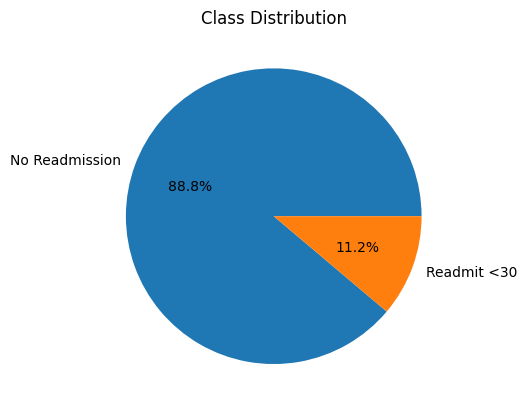

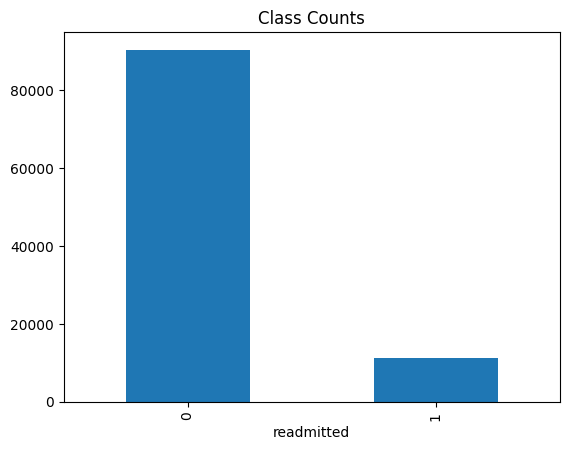

In [ ]:
# SINIF DAĞILIMI ANALİZİ

class_counts = df["readmitted"].value_counts()

# Pasta grafik
class_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["No Readmission", "Readmit <30"],
    title="Class Distribution"
)
plt.ylabel("")
plt.show()

# Çubuk grafik
class_counts.plot(kind="bar", title="Class Counts")
plt.show()

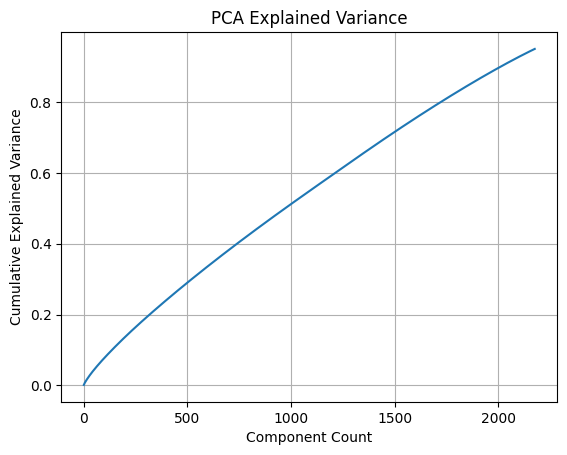

In [ ]:
# ÖN İŞLEME + PCA

# Özellikler (X) ve hedef (y)
X = df.drop("readmitted", axis=1).values
y = df["readmitted"].values

# Standartlaştırma (Mean=0, Std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Boyut indirgeme (PCA – %95 varyans korunur)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# PCA açıklanan varyans grafiği
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Component Count")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

In [ ]:
# FEATURE ENGINEERING / DIMENSION REDUCTION ÖZET TABLOSU

fe_dr_table = pd.DataFrame({
    "Applied FE": [
        "Missing Value Imputation, One-Hot Encoding, Standard Scaling"
    ],
    "Applied DR": [
        "PCA (95% Explained Variance)"
    ],
    "Final Feature Count": [
        X_pca.shape[1]
    ]
})

print("\nFEATURE ENGINEERING / DIMENSION REDUCTION SUMMARY")
display(fe_dr_table)


FEATURE ENGINEERING / DIMENSION REDUCTION SUMMARY


,Applied FE,Applied DR,Final Feature Count
0,"Missing Value Imputation, One-Hot Encoding, St...",PCA (95% Explained Variance),2178


In [ ]:
# TRAIN / TEST AYIRMA
# Stratify → sınıf oranları korunur

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
# PYTORCH DATALOADER

def make_loader(X, y, batch_size=256, shuffle=False):
    """
    Numpy arrayleri PyTorch TensorDataset'e çevirir
    """
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32).view(-1, 1)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
test_loader  = make_loader(X_test, y_test)

In [ ]:
# MODEL TANIMLARI

# Derin Çok Katmanlı Algılayıcı (Deep MLP)
class DeepMLP(nn.Module):
    def __init__(self, in_dim, hidden, drop):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.BatchNorm1d(hidden),
            nn.Dropout(drop),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden // 2),
            nn.Dropout(drop),
            nn.Linear(hidden // 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Residual bağlantılı MLP (Skip Connection)
class ResidualMLP(nn.Module):
    def __init__(self, in_dim, hidden):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.out = nn.Linear(hidden, 1)

    def forward(self, x):
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h) + h)  # Residual bağlantı
        return torch.sigmoid(self.out(h))


In [ ]:
# MODEL EĞİTİM FONKSİYONU

def train_model(model, epochs=25, lr=1e-3):

    # Modeli eğitir ve epoch bazlı loss değerlerini döndürür

    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    losses = []

    for epoch in range(epochs):
        epoch_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        losses.append(epoch_loss / len(train_loader))

    return losses

In [ ]:
# HYPERPARAMETER OPTIMIZATION (OPTUNA)

def objective(trial):

    # Optuna için amaç fonksiyonu

    hidden = trial.suggest_int("hidden", 128, 512)
    drop = trial.suggest_float("dropout", 0.2, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = DeepMLP(X_train.shape[1], hidden, drop).to(device)
    train_model(model, epochs=5, lr=lr)

    model.eval()
    probs = []

    with torch.no_grad():
        for xb, _ in test_loader:
            probs.extend(model(xb.to(device)).cpu().numpy())

    return roc_auc_score(y_test, probs)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

best_params = study.best_params
print("Best Hyperparameters:", best_params)

[I 2026-01-09 10:19:33,888] A new study created in memory with name: no-name-3f8a2ced-6afe-463e-9166-f53e31724682
[I 2026-01-09 10:19:45,280] Trial 0 finished with value: 0.6302204086431242 and parameters: {'hidden': 500, 'dropout': 0.2980788417843314, 'lr': 0.0004482710754686175}. Best is trial 0 with value: 0.6302204086431242.
[I 2026-01-09 10:19:53,696] Trial 1 finished with value: 0.6331228356899139 and parameters: {'hidden': 224, 'dropout': 0.40978928213682286, 'lr': 0.005421589935429082}. Best is trial 1 with value: 0.6331228356899139.
[I 2026-01-09 10:20:01,646] Trial 2 finished with value: 0.6274902022921705 and parameters: {'hidden': 449, 'dropout': 0.42383595815599234, 'lr': 0.0001139671650442375}. Best is trial 1 with value: 0.6331228356899139.
[I 2026-01-09 10:20:10,369] Trial 3 finished with value: 0.6302105100623031 and parameters: {'hidden': 438, 'dropout': 0.216224444781001, 'lr': 0.008967325822857534}. Best is trial 1 with value: 0.6331228356899139.
[I 2026-01-09 10:20

Best Hyperparameters: {'hidden': 317, 'dropout': 0.3575229092209968, 'lr': 0.0014346625589511605}


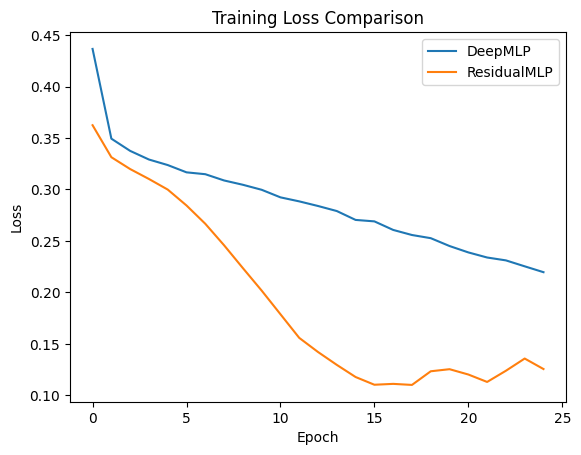

In [ ]:
# FINAL MODEL EĞİTİMİ

mlp = DeepMLP(
    X_train.shape[1],
    best_params["hidden"],
    best_params["dropout"]
).to(device)

res = ResidualMLP(
    X_train.shape[1],
    best_params["hidden"]
).to(device)

loss_mlp = train_model(mlp, lr=best_params["lr"])
loss_res = train_model(res, lr=best_params["lr"])

# Eğitim kaybı karşılaştırma grafiği
plt.plot(loss_mlp, label="DeepMLP")
plt.plot(loss_res, label="ResidualMLP")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()


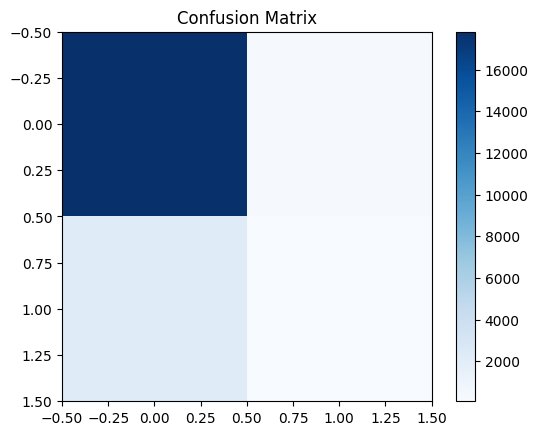

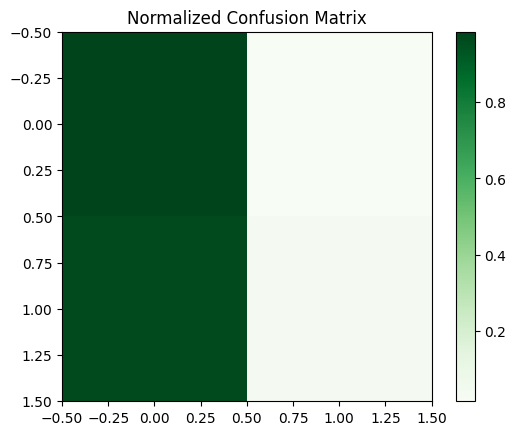

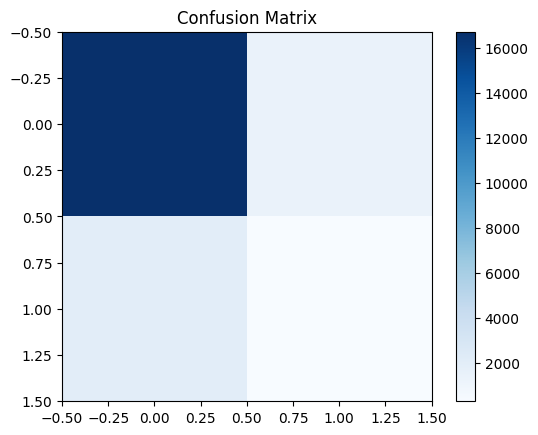

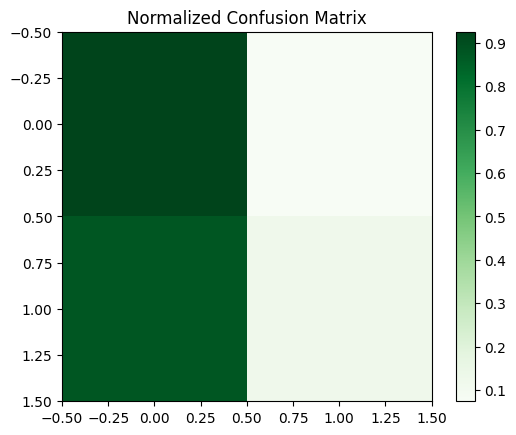

In [ ]:
# MODEL DEĞERLENDİRME FONKSİYONU

def evaluate_model(model):

    # Modeli test seti üzerinde değerlendirir

    model.eval()
    probs = []

    with torch.no_grad():
        for xb, _ in test_loader:
            probs.extend(model(xb.to(device)).cpu().numpy())

    probs = np.array(probs)
    preds = (probs > 0.5).astype(int)

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    plt.imshow(cm, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.colorbar()
    plt.show()

    plt.imshow(cm_norm, cmap="Greens")
    plt.title("Normalized Confusion Matrix")
    plt.colorbar()
    plt.show()

    report = classification_report(y_test, preds, output_dict=True)

    metrics = {
        "Accuracy": accuracy_score(y_test, preds),
        "Balanced Accuracy": balanced_accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs)
    }

    return metrics, report, probs

# Modellerin değerlendirilmesi
m1, r1, p1 = evaluate_model(mlp)
m2, r2, p2 = evaluate_model(res)

In [ ]:
# GENEL PERFORMANS KARŞILAŞTIRMA TABLOSU

results = pd.DataFrame([m1, m2], index=["DeepMLP", "ResidualMLP"])

def highlight_best(col):
    return ["font-weight: bold" if v == col.max() else "" for v in col]

print("\nGENEL PERFORMANS KARŞILAŞTIRMA TABLOSU")
display(results.style.apply(highlight_best, axis=0))


GENEL PERFORMANS KARŞILAŞTIRMA TABLOSU


,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
DeepMLP,0.879336,0.510671,0.234957,0.036107,0.062595,0.602663
ResidualMLP,0.836199,0.524127,0.171711,0.122413,0.142931,0.564555


In [ ]:
# SINIF BAZLI KARŞILAŞTIRMA TABLOSU (PDF MADDE 9.b)

classwise = pd.DataFrame({
    ("No Readmit", "Precision"): [r1["0"]["precision"], r2["0"]["precision"]],
    ("No Readmit", "Recall"):    [r1["0"]["recall"], r2["0"]["recall"]],
    ("No Readmit", "F1"):        [r1["0"]["f1-score"], r2["0"]["f1-score"]],
    ("Readmit <30", "Precision"): [r1["1"]["precision"], r2["1"]["precision"]],
    ("Readmit <30", "Recall"):    [r1["1"]["recall"], r2["1"]["recall"]],
    ("Readmit <30", "F1"):        [r1["1"]["f1-score"], r2["1"]["f1-score"]],
}, index=["DeepMLP", "ResidualMLP"])

print("\nSINIF BAZLI KARŞILAŞTIRMA TABLOSU")
display(classwise)


SINIF BAZLI KARŞILAŞTIRMA TABLOSU


No Readmit                     Readmit <30                    
             Precision    Recall        F1   Precision    Recall        F1
DeepMLP       0.890577  0.985235  0.935518    0.234957  0.036107  0.062595
ResidualMLP   0.893622  0.925842  0.909446    0.171711  0.122413  0.142931

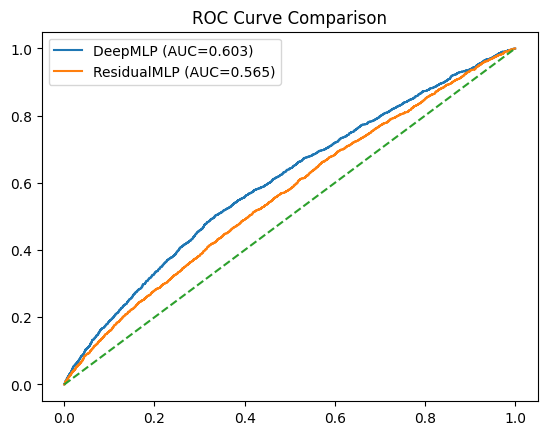

In [ ]:
# ROC EĞRİLERİ

fpr1, tpr1, _ = roc_curve(y_test, p1)
fpr2, tpr2, _ = roc_curve(y_test, p2)

plt.plot(fpr1, tpr1, label=f"DeepMLP (AUC={m1['ROC-AUC']:.3f})")
plt.plot(fpr2, tpr2, label=f"ResidualMLP (AUC={m2['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], "--")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
# EN İYİ MODELİN SEÇİMİ VE YORUMU

best_model = results["ROC-AUC"].idxmax()

print(f"EN İYİ MODEL: {best_model}")

EN İYİ MODEL: DeepMLP


In [ ]:
# EN İYİ MODELİN KAYDEDİLMESİ

# En iyi model ROC-AUC değerine göre seçilir
if best_model == "DeepMLP":
    final_model = mlp
    model_name = "DeepMLP"
else:
    final_model = res
    model_name = "ResidualMLP"

# Model evaluation moduna alınır
final_model.eval()

# Model ağırlıkları (.pth) formatında kaydedilir
model_path = f"{model_name}_best_model.pth"
torch.save(final_model.state_dict(), model_path)

print(f"""
MODEL KAYDEDİLDİ ✔
------------------
Model Adı : {model_name}
Dosya     : {model_path}

Bu model ROC-AUC metriğine göre en iyi performansı göstermiştir
ve final model olarak seçilmiştir.
""")



MODEL KAYDEDİLDİ ✔
------------------
Model Adı : DeepMLP
Dosya     : DeepMLP_best_model.pth

Bu model ROC-AUC metriğine göre en iyi performansı göstermiştir
ve final model olarak seçilmiştir.

